# ML - K-Vecinos más Cercanos (KNN)

In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 1: Carga del conjunto de datos


In [4]:
df = pd.read_csv('../data/raw/winequality-red.csv', sep=';')
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [5]:
df['quality'] = np.select([df['quality'] <= 4,(df['quality'] > 4) & (df['quality'] <= 6), df['quality'] > 6], [0, 1, 2])
df['quality'].value_counts()

quality
1    1319
2     217
0      63
Name: count, dtype: int64

In [6]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1


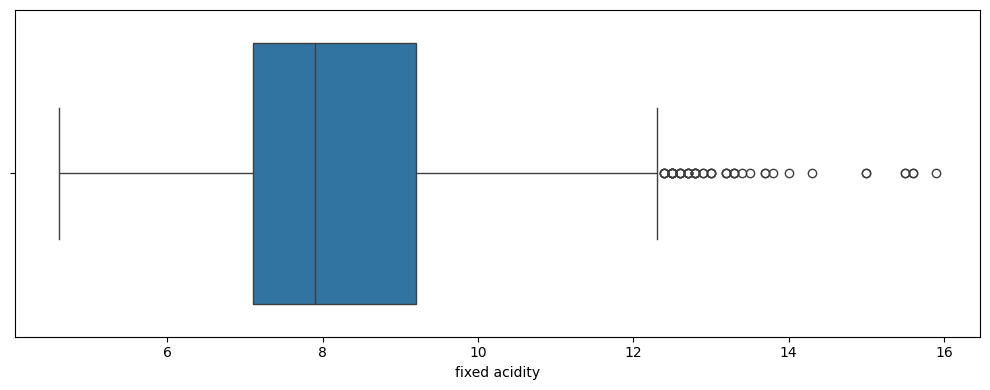

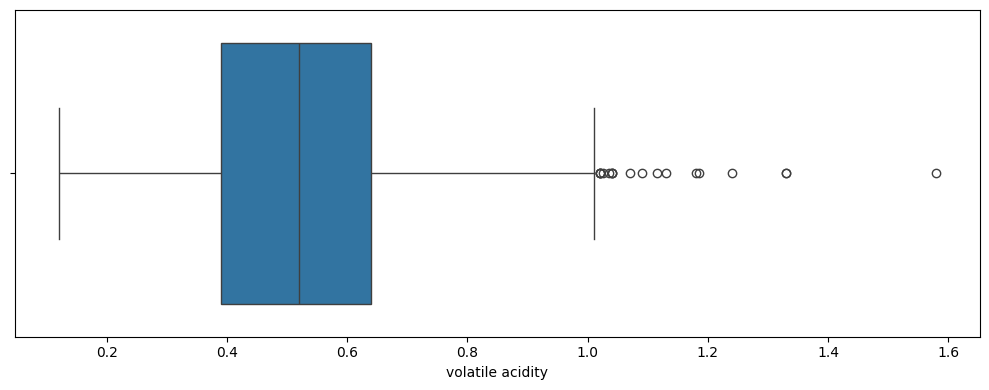

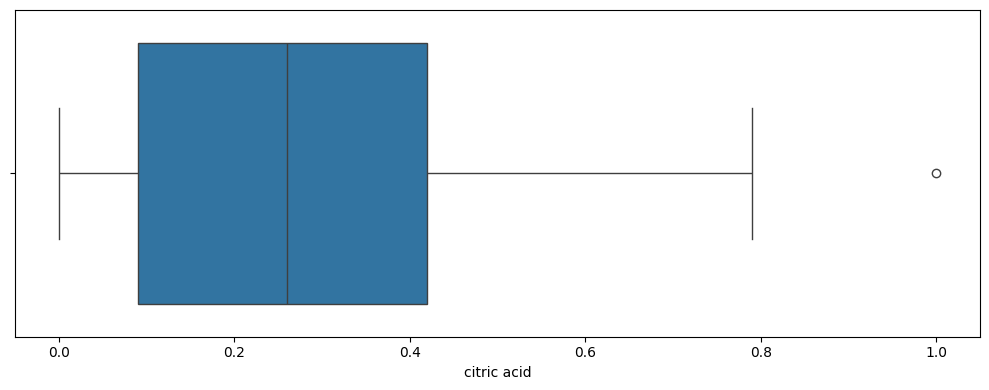

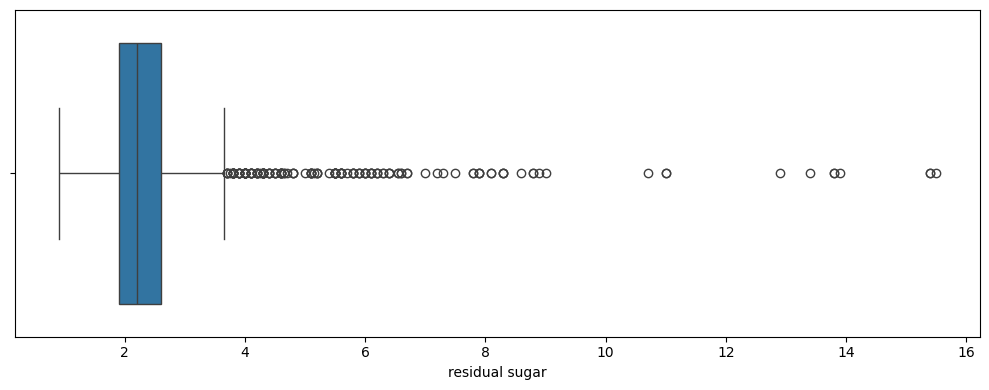

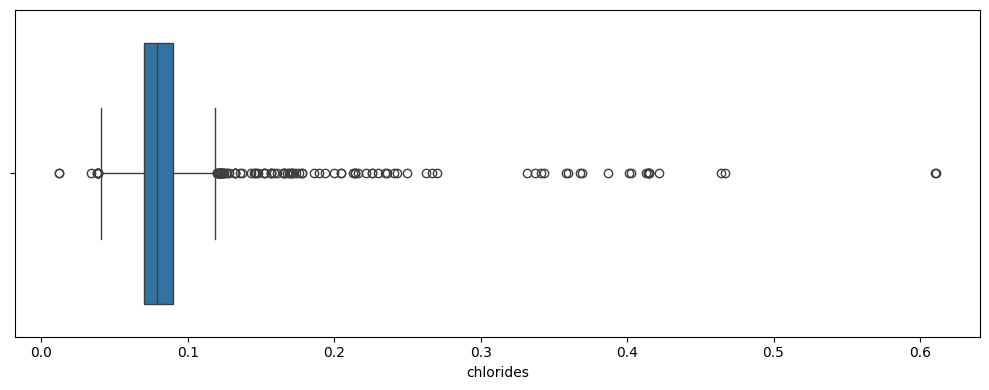

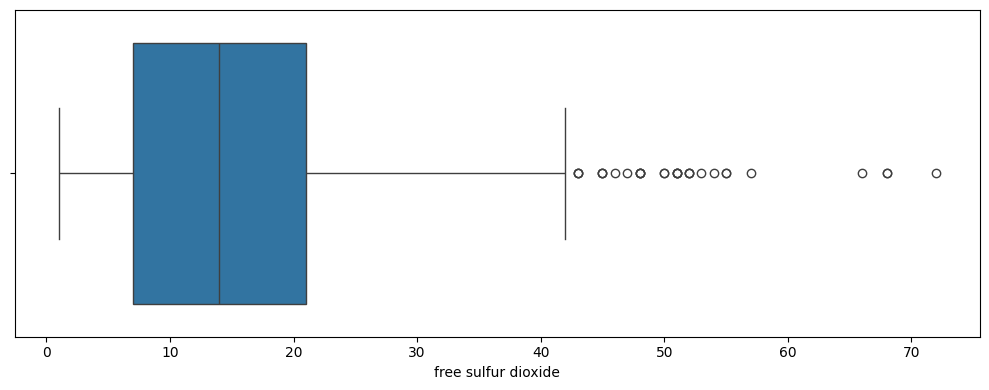

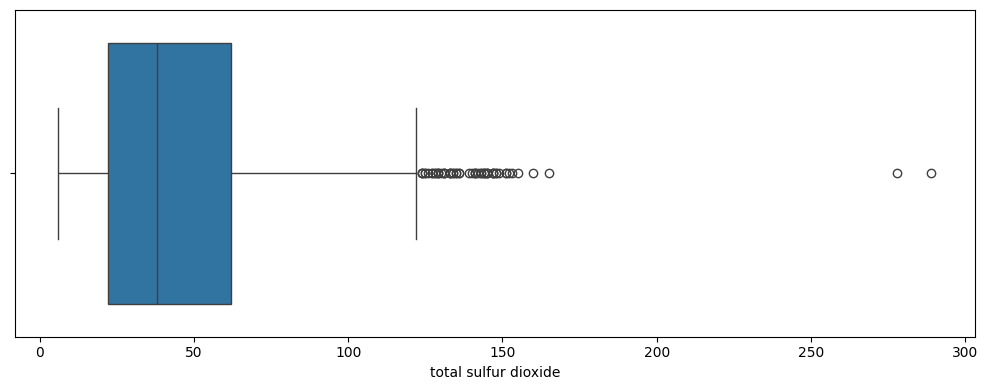

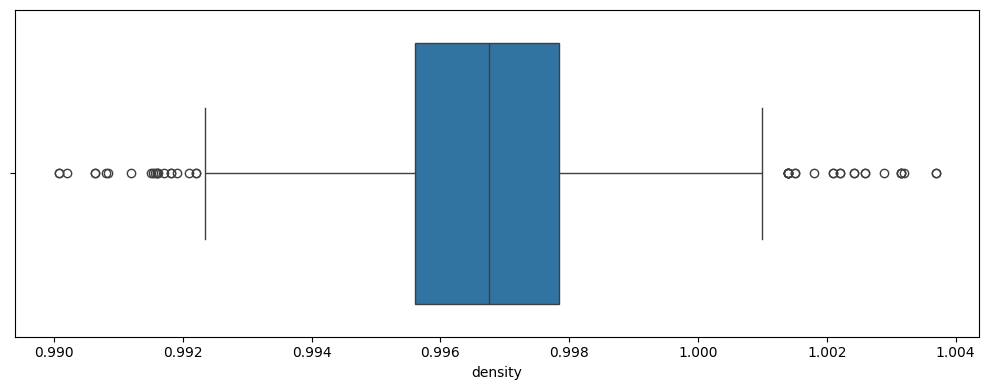

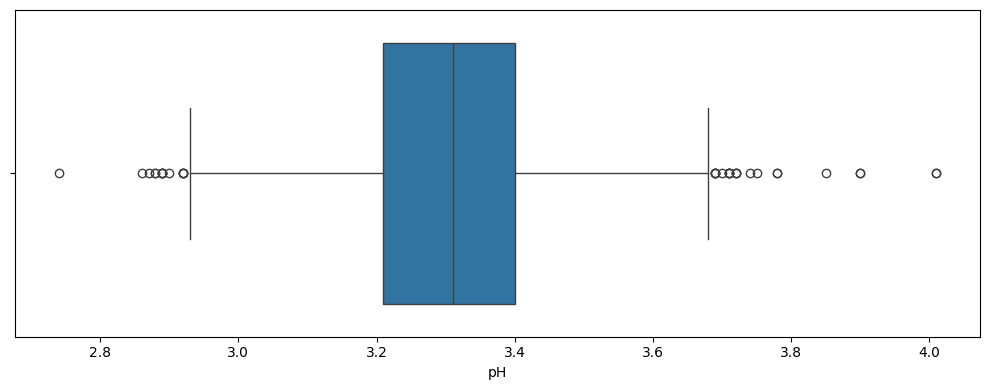

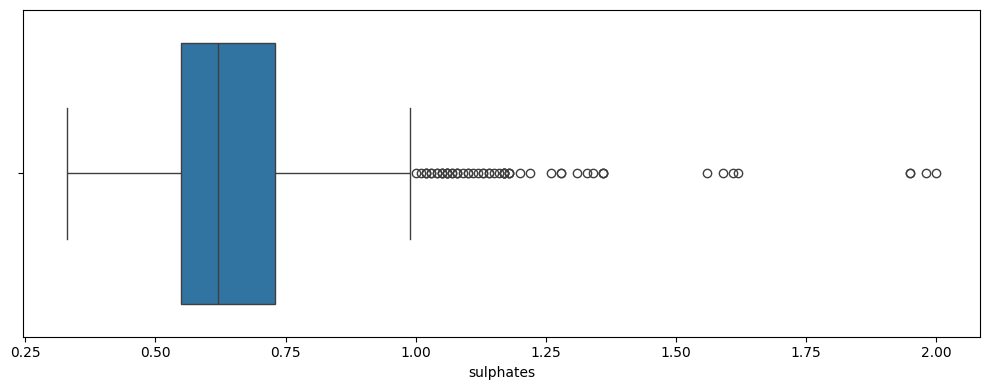

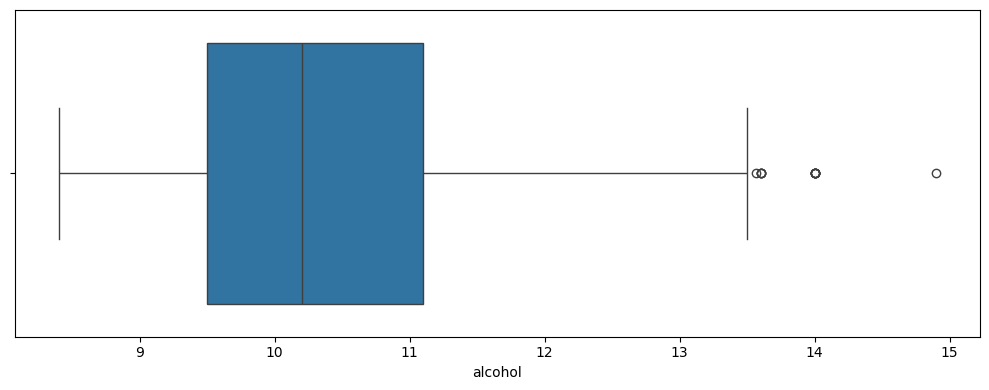

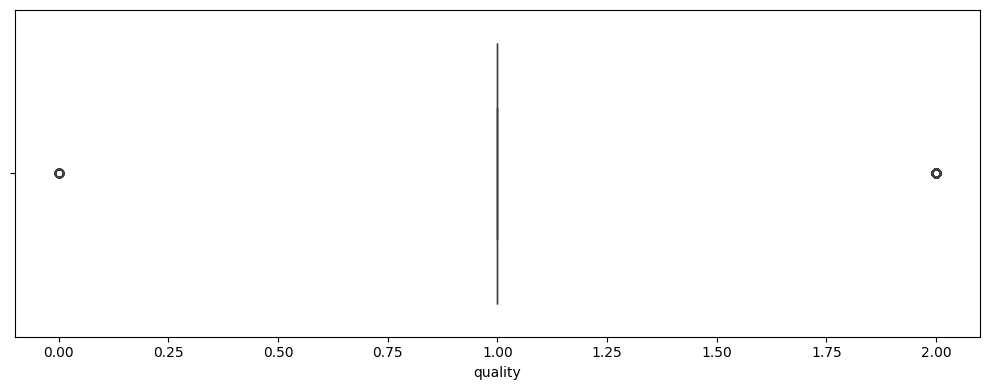

In [61]:
for col in df.columns:
    plt.figure(figsize=(10, 4)) 
    
    sns.boxplot(data=df, x=col)

    plt.tight_layout()

## PASO 2: Entrenamos el modelo KNN

### Split (Segundo enfoque)

In [7]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
751,8.3,0.650,0.10,2.9,0.089,17.0,40.0,0.99803,3.29,0.55,9.5
370,6.9,0.765,0.02,2.3,0.063,35.0,63.0,0.99750,3.57,0.78,9.9
374,14.0,0.410,0.63,3.8,0.089,6.0,47.0,1.00140,3.01,0.81,10.8
537,8.1,0.825,0.24,2.1,0.084,5.0,13.0,0.99720,3.37,0.77,10.7
708,7.8,0.545,0.12,2.5,0.068,11.0,35.0,0.99600,3.34,0.61,11.6
...,...,...,...,...,...,...,...,...,...,...,...
368,10.3,0.340,0.52,2.8,0.159,15.0,75.0,0.99980,3.18,0.64,9.4
48,6.4,0.400,0.23,1.6,0.066,5.0,12.0,0.99580,3.34,0.56,9.2
772,9.5,0.570,0.27,2.3,0.082,23.0,144.0,0.99782,3.27,0.55,9.4
1231,7.8,0.815,0.01,2.6,0.074,48.0,90.0,0.99621,3.38,0.62,10.8


### Scaling - Escalado Mínimo-Máximo (variables numéricas)

In [8]:
min_max_scaler = MinMaxScaler()
# Ajustamos solo con los datos de entrenamiento
min_max_scaler.fit(X_train)

X_train_scal = min_max_scaler.transform(X_train)
X_train_scal = pd.DataFrame(X_train_scal, index=X_train.index, columns=X_train.columns)

X_test_scal = min_max_scaler.transform(X_test)
X_test_scal = pd.DataFrame(X_test_scal, index=X_test.index, columns=X_test.columns)

X_train_scal

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
751,0.321429,0.363014,0.10,0.137931,0.128548,0.225352,0.120141,0.584435,0.433071,0.131737,0.169231
370,0.196429,0.441781,0.02,0.096552,0.085142,0.478873,0.201413,0.545521,0.653543,0.269461,0.230769
374,0.830357,0.198630,0.63,0.200000,0.128548,0.070423,0.144876,0.831865,0.212598,0.287425,0.369231
537,0.303571,0.482877,0.24,0.082759,0.120200,0.056338,0.024735,0.523495,0.496063,0.263473,0.353846
708,0.276786,0.291096,0.12,0.110345,0.093489,0.140845,0.102473,0.435389,0.472441,0.167665,0.492308
...,...,...,...,...,...,...,...,...,...,...,...
368,0.500000,0.150685,0.52,0.131034,0.245409,0.197183,0.243816,0.714391,0.346457,0.185629,0.153846
48,0.151786,0.191781,0.23,0.048276,0.090150,0.056338,0.021201,0.420705,0.472441,0.137725,0.123077
772,0.428571,0.308219,0.27,0.096552,0.116861,0.309859,0.487633,0.569016,0.417323,0.131737,0.153846
1231,0.276786,0.476027,0.01,0.117241,0.103506,0.661972,0.296820,0.450808,0.503937,0.173653,0.369231


### Iniciamos y entrenamos el modelo

In [29]:
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

### Predicciones

In [30]:
y_pred_test = knn_model.predict(X_test)
y_pred_train = knn_model.predict(X_train)

In [31]:
accuracy_score(y_test, y_pred_test)

0.803125

Text(0, 0.5, 'Real')

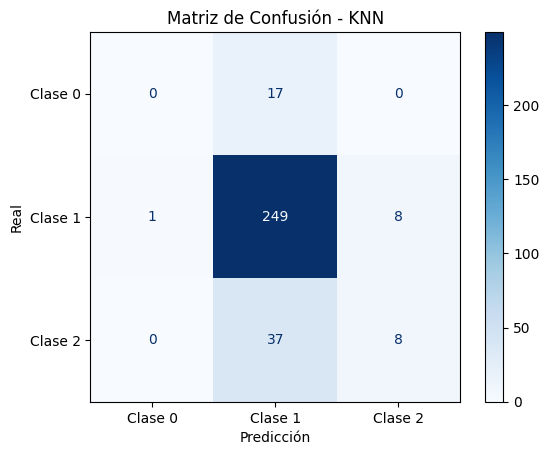

In [32]:
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Clase 0", "Clase 1", "Clase 2"])

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - KNN")
plt.xlabel("Predicción")
plt.ylabel("Real")


In [35]:
report_knn= classification_report(y_test, y_pred_test)
print(report_knn)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.82      0.97      0.89       258
           2       0.50      0.18      0.26        45

    accuracy                           0.80       320
   macro avg       0.44      0.38      0.38       320
weighted avg       0.73      0.80      0.75       320



In [12]:
# Reducimos el desbalance con SMOTE
smote = SMOTE(random_state=21)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

### Optimización de k

In [39]:
accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k = {k} → Accuracy = {acc:.3f}")

k = 1 → Accuracy = 0.816
k = 2 → Accuracy = 0.809
k = 3 → Accuracy = 0.822
k = 4 → Accuracy = 0.816
k = 5 → Accuracy = 0.828
k = 6 → Accuracy = 0.800
k = 7 → Accuracy = 0.806
k = 8 → Accuracy = 0.806
k = 9 → Accuracy = 0.803
k = 10 → Accuracy = 0.803
k = 11 → Accuracy = 0.803
k = 12 → Accuracy = 0.803
k = 13 → Accuracy = 0.812
k = 14 → Accuracy = 0.812
k = 15 → Accuracy = 0.812
k = 16 → Accuracy = 0.812
k = 17 → Accuracy = 0.819
k = 18 → Accuracy = 0.816
k = 19 → Accuracy = 0.816
k = 20 → Accuracy = 0.812


In [48]:
max(accuracies)

0.828125

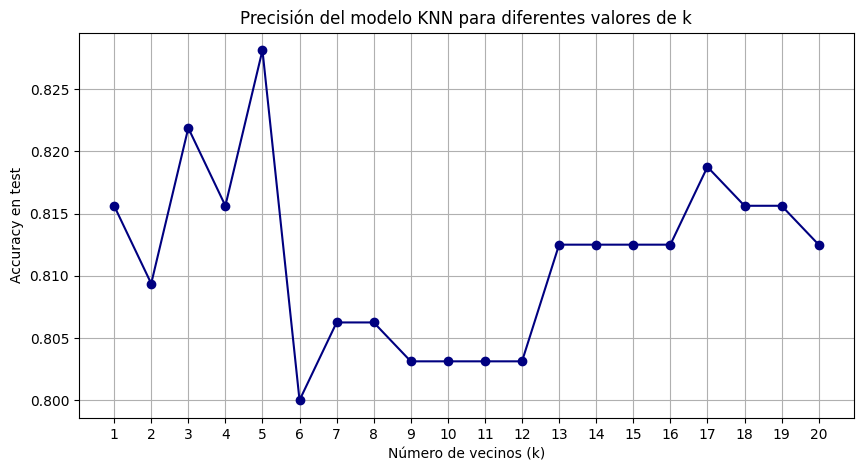

In [38]:
# Graficar
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), accuracies, marker='o', linestyle='-', color='navy')
plt.title("Precisión del modelo KNN para diferentes valores de k")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy en test")
plt.xticks(range(1, 21))
plt.grid(True)

### Optimización con GridSearchCV

In [55]:
param_grid = {'n_neighbors': list(range(1, 21)),
              'weights': ['uniform', 'distance'],
              'metric': ['euclidean', 'manhattan']}


grid = GridSearchCV(knn_model, param_grid, cv=5, scoring='accuracy')

In [56]:
grid.fit(X_train, y_train)
grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}

In [57]:
knn_grid_model = grid.best_estimator_
y_pred_grid = knn_grid_model.predict(X_test)

In [58]:
accuracy_score(y_test, y_pred_grid)

0.865625

In [59]:
report_knn_grid= classification_report(y_test, y_pred_grid)
print(report_knn_grid)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.87      0.98      0.92       258
           2       0.85      0.51      0.64        45

    accuracy                           0.87       320
   macro avg       0.57      0.50      0.52       320
weighted avg       0.82      0.87      0.83       320



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
